In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import ListedColormap
from IPython.display import display
from matplotlib.ticker import MaxNLocator, StrMethodFormatter
from scipy.interpolate import make_interp_spline
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# โหลดฟอนต์ไทย
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New')

In [ ]:
file_path = '/content/SLforecast.xlsx'
xls = pd.ExcelFile(file_path)
print("Sheet ทั้งหมด:", xls.sheet_names)
df = xls.parse(xls.sheet_names[0])
print("\nข้อมูล 5 แถวแรก:")
print(df.head(5))

In [ ]:
df.dropna(how='all', inplace=True)
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)


# ลบคอลัมน์ที่ไม่จำเป็น
columns_to_drop = ['Unnamed: 0', 'หมายเหตุ', 'Note']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)
# ลบแถวที่มี missing เกิน 50% (ยกเว้นค่า 0)
df = df[df.isnull().mean(axis=1) < 0.5]
# เติมค่าว่างด้วยข้อมูลก่อนหน้า
df.fillna(method='ffill', inplace=True)
# แปลงคอลัมน์ตัวเลขจาก object
for col in df.columns:
    if col != 'ID' and df[col].dtype == 'object':
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass
print("\n ตรวจสอบค่าติดลบในคอลัมน์ตัวเลข:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
has_negative = False
for col in numeric_cols:
    if (df[col] < 0).any():
        print(f"- พบค่าติดลบในคอลัมน์: {col}")
        has_negative = True
if not has_negative:
    print("ไม่พบค่าติดลบในคอลัมน์ใดๆ")

print("\n สถิติเบื้องต้น:")
print(df.describe())

duplicates = df.duplicated().sum()
print(f"\n จำนวนแถวที่ซ้ำกัน: {duplicates}")

if 'ID' in df.columns:
    unique_ids = df['ID'].nunique()
    print(f"\n จำนวน ID ที่ไม่ซ้ำกัน: {unique_ids}")
    print("ตัวอย่าง ID:", df['ID'].unique()[:5])
else:
    print("\n ไม่พบคอลัมน์ 'ID'")

if 'ปี' in df.columns:
    print("\n จำนวนข้อมูลในแต่ละปี:")
    print(df['ปี'].value_counts().sort_index())
else:
    print("\n ไม่พบคอลัมน์ 'ปี'")

df.columns = df.columns.str.strip().str.lower()


 ตรวจสอบค่าติดลบในคอลัมน์ตัวเลข:
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ ม.ค.
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ ก.พ.
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ มี.ค.
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ เม.ย.
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ พ.ค.
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ มิ.ย.
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ ก.ค.
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ ส.ค.
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ ก.ย.
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ ต.ค.
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ พ.ย.
- พบค่าติดลบในคอลัมน์: ไฟฟ้าที่ใช้เองจากโซลาร์ ธ.ค.
- พบค่าติดลบในคอลัมน์: ใช้เองรวมต่อปี
- พบค่าติดลบในคอลัมน์: รายได้ที่หายไป(บาท)
- พบค่าติดลบในคอลัมน์: ขาดกำไรจากการใช้เอง (บาท)
- พบค่าติดลบในคอลัมน์: Lost Margin (%)

 สถิติเบื้องต้น:
                 id  กำลังการผลิตติดตั้ง(mwh)  กำลังการผลิตติดตั้ง(kwh)  \
count   9520.000000               9520.000000               9520.000000   
me

/tmp/ipython-input-813355322.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
region_map = {
    # ภาคกลาง (รวม ภาคกลาง + ภาคตะวันตก + ภาคตะวันออก)
    'กรุงเทพมหานคร': 'กลาง', 'นนทบุรี': 'กลาง', 'ปทุมธานี': 'กลาง',
    'พระนครศรีอยุธยา': 'กลาง', 'ลพบุรี': 'กลาง', 'สระบุรี': 'กลาง',
    'สมุทรปราการ': 'กลาง', 'สมุทรสาคร': 'กลาง', 'นครปฐม': 'กลาง',
    'สุพรรณบุรี': 'กลาง', 'อ่างทอง': 'กลาง', 'ชัยนาท': 'กลาง',
    'สิงห์บุรี': 'กลาง', 'สมุทรสงคราม': 'กลาง', 'นครนายก': 'กลาง',
    'อุทัยธานี': 'กลาง',
    # เดิมภาคตะวันตก → รวมเข้ากลาง
    'ประจวบคีรีขันธ์': 'กลาง', 'กาญจนบุรี': 'กลาง',
    'ราชบุรี': 'กลาง', 'เพชรบุรี': 'กลาง',
    # เดิมภาคตะวันออก → รวมเข้ากลาง
    'ชลบุรี': 'กลาง', 'ระยอง': 'กลาง', 'จันทบุรี': 'กลาง',
    'ตราด': 'กลาง', 'ฉะเชิงเทรา': 'กลาง', 'สระแก้ว': 'กลาง',
    'ปราจีนบุรี': 'กลาง',

    # ภาคเหนือ
    'เชียงใหม่': 'เหนือ', 'เชียงราย': 'เหนือ', 'ลำพูน': 'เหนือ',
    'ลำปาง': 'เหนือ', 'พะเยา': 'เหนือ', 'น่าน': 'เหนือ', 'แพร่': 'เหนือ',
    'แม่ฮ่องสอน': 'เหนือ', 'พิษณุโลก': 'เหนือ', 'พิจิตร': 'เหนือ',
    'สุโขทัย': 'เหนือ', 'กำแพงเพชร': 'เหนือ', 'อุตรดิตถ์': 'เหนือ',
    'ตาก': 'เหนือ', 'เพชรบูรณ์': 'เหนือ', 'นครสวรรค์': 'เหนือ',

    # ภาคอีสาน
    'นครราชสีมา': 'อีสาน', 'ขอนแก่น': 'อีสาน',
    'อุดรธานี': 'อีสาน', 'อุบลราชธานี': 'อีสาน',
    'มหาสารคาม': 'อีสาน', 'ร้อยเอ็ด': 'อีสาน',
    'บุรีรัมย์': 'อีสาน', 'ศรีสะเกษ': 'อีสาน',
    'สกลนคร': 'อีสาน', 'นครพนม': 'อีสาน',
    'ชัยภูมิ': 'อีสาน', 'กาฬสินธุ์': 'อีสาน',
    'หนองคาย': 'อีสาน', 'เลย': 'อีสาน',
    'สุรินทร์': 'อีสาน', 'บึงกาฬ': 'อีสาน',
    'ยโสธร': 'อีสาน', 'มุกดาหาร': 'อีสาน',
    'หนองบัวลำภู': 'อีสาน', 'หนองบัวลําภู': 'อีสาน',
    'อำนาจเจริญ': 'อีสาน',

    # ภาคใต้
    'นครศรีธรรมราช': 'ใต้', 'สุราษฎร์ธานี': 'ใต้', 'สงขลา': 'ใต้',
    'ภูเก็ต': 'ใต้', 'ตรัง': 'ใต้', 'พัทลุง': 'ใต้', 'ปัตตานี': 'ใต้',
    'ยะลา': 'ใต้', 'นราธิวาส': 'ใต้', 'กระบี่': 'ใต้', 'ชุมพร': 'ใต้',
    'สตูล': 'ใต้', 'ระนอง': 'ใต้', 'พังงา': 'ใต้'
}


In [ ]:
df['ภาค'] = df['จังหวัด'].map(region_map)
# รวมคอลัมน์ขายคืนของทั้งปีอย่างยืดหยุ่น
sellback_cols = [col for col in df.columns if 'ขายคืนรวม' in col]
df['ขายคืนรวมต่อปี'] = df[sellback_cols].sum(axis=1)
# แม็ปจังหวัด → ภาค (ใช้ในหลายกราฟ)
province_region_map = df.drop_duplicates(subset='จังหวัด').set_index('จังหวัด')['ภาค'].to_dict()

selfuse_cols = [col for col in df.columns if 'ไฟฟ้าที่ใช้เองจากโซลาร์' in col]
df['ใช้เองรวมต่อปี'] = df[selfuse_cols].sum(axis=1)

In [ ]:
#ราคาขายไฟปกติ = 4.00 บาท/หน่วย
price_normal = 4.00
lost_revenue = df['ใช้เองรวมต่อปี'] * price_normal
df['รายได้ที่หายไป'] = lost_revenue
#ราคารับซื้อคืน = 2.20 บาท/หน่วย
price_buyback = 2.20
cost_buyback = df['ขายคืนรวมต่อปี'] * price_buyback
df['ภาระซื้อคืน'] = cost_buyback


กราฟค่าปกติ

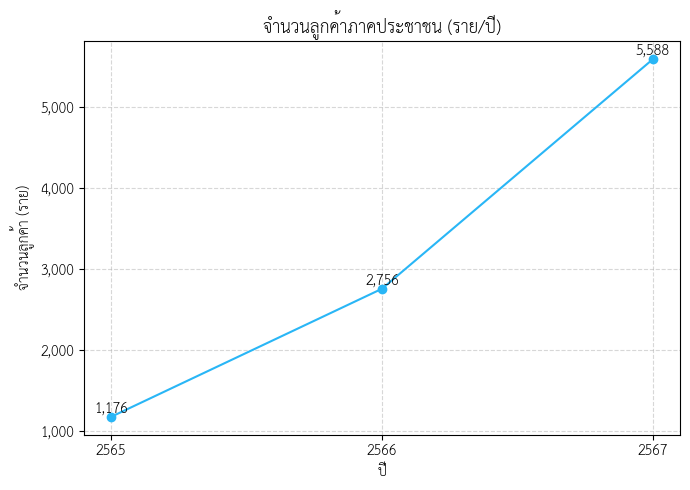

In [ ]:
plt.figure(figsize=(7, 5))
customer_per_year = df['ปี'].value_counts().sort_index()
plt.plot(customer_per_year.index, customer_per_year.values, marker='o', color='#29B6F6')
plt.title('จำนวนลูกค้าภาคประชาชน (ราย/ปี)')
plt.xlabel('ปี')
plt.ylabel('จำนวนลูกค้า (ราย)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(customer_per_year.index, customer_per_year.index.astype(int))

# ฟอร์แมตตัวเลขแกน y ให้มีลูกน้ำ
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))

# ใส่ label ตัวเลข พร้อมลูกน้ำ
for x, y in zip(customer_per_year.index, customer_per_year.values):
    plt.text(x, y + 1, f'{y:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('จำนวนลูกค้าภาคประชาชน.png', dpi=300)
plt.show()


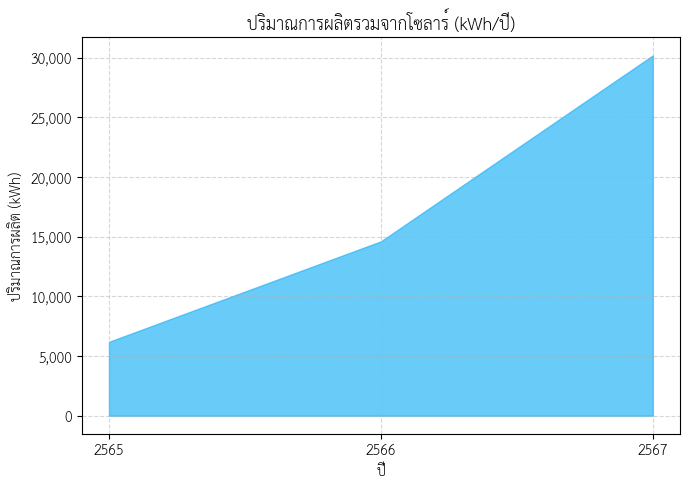

In [ ]:

plt.figure(figsize=(7, 5))
capacity_per_year = df.groupby('ปี')['กำลังการผลิตติดตั้ง(kwh)'].sum().sort_index()
plt.fill_between(capacity_per_year.index, capacity_per_year.values, color='#29B6F6', alpha=0.7)
plt.title('ปริมาณการผลิตรวมจากโซลาร์ (kWh/ปี)')
plt.xlabel('ปี')
plt.ylabel('ปริมาณการผลิต (kWh)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(capacity_per_year.index, capacity_per_year.index.astype(int))

# ฟอร์แมตตัวเลขแกน y ให้มีลูกน้ำ
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig('กำลังการผลิตรวมจากโซลาร์.png', dpi=300, bbox_inches='tight')
plt.show()


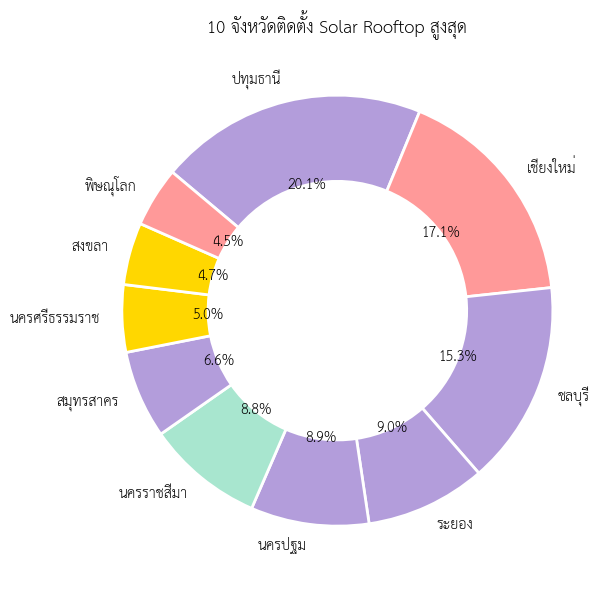

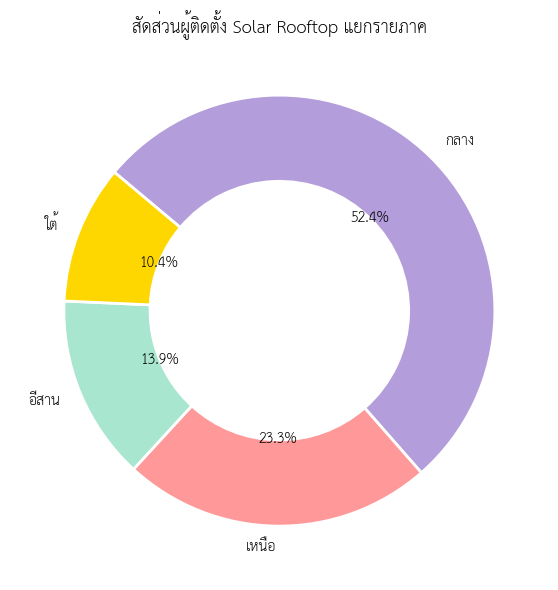

In [ ]:
region_colors = {
    'เหนือ': '#FF9999',
    'กลาง': '#B39DDB',
    'อีสาน': '#A8E6CF',
    'ใต้': '#FFD700'
}

# === Mapping จังหวัด -> ภาค ===
province_to_region = df.drop_duplicates(subset='จังหวัด').set_index('จังหวัด')['ภาค'].to_dict()

# --- 10 จังหวัดติดตั้งมากสุด ---
plt.figure(figsize=(7, 6))
top_provinces = df['จังหวัด'].value_counts().head(10)
top_province_regions = [province_to_region[prov] for prov in top_provinces.index]
top_province_colors = [region_colors[region] for region in top_province_regions]

top_provinces.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    counterclock=False,
    colors=top_province_colors,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)  # ✅ วงเล็บปิด
)
plt.title('10 จังหวัดติดตั้ง Solar Rooftop สูงสุด')
plt.ylabel('')
plt.tight_layout()
plt.savefig('10 จังหวัดติดตั้ง Solar Rooftop สูงสุด.png', dpi=300, bbox_inches='tight')
plt.show()

# --- สัดส่วนแยกรายภาค ---
plt.figure(figsize=(7, 6))
region_counts = df['ภาค'].value_counts()
region_color_list = [region_colors[reg] for reg in region_counts.index]

region_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    counterclock=False,
    colors=region_color_list,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)  # ✅ วงเล็บปิด
)
plt.title('สัดส่วนผู้ติดตั้ง Solar Rooftop แยกรายภาค')
plt.ylabel('')
plt.tight_layout()
plt.savefig('สัดส่วนผู้ติดตั้ง Solar Rooftop แยกรายภาค.png', dpi=300, bbox_inches='tight')
plt.show()


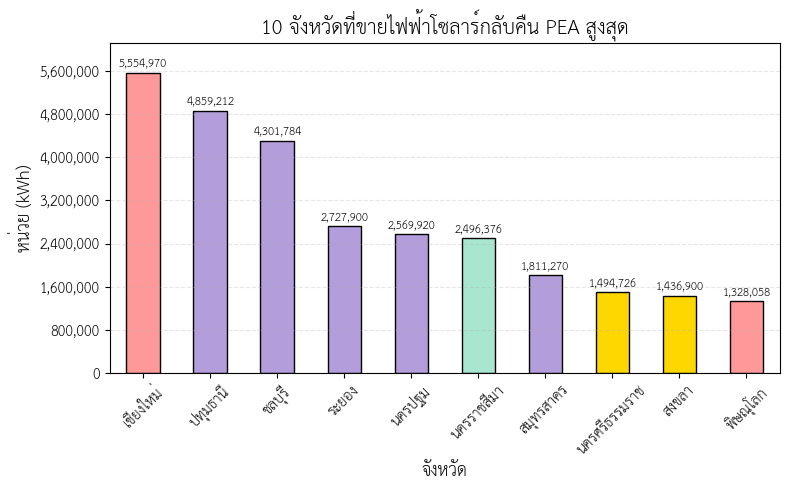

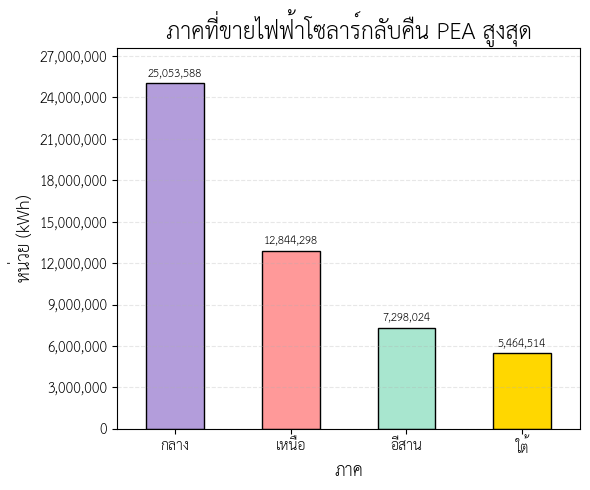

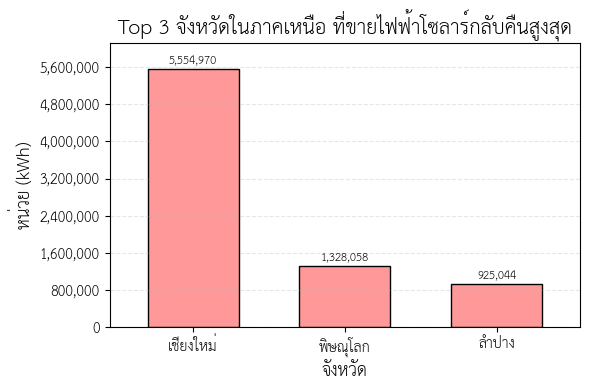

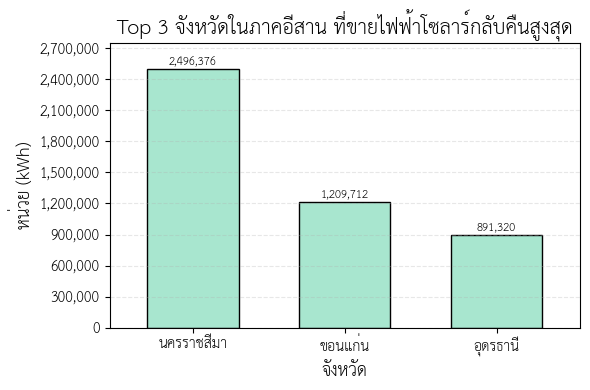

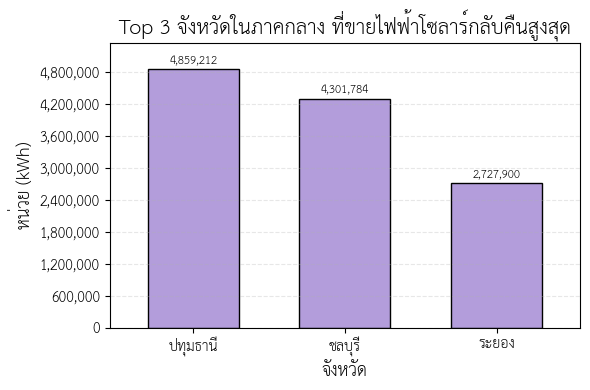

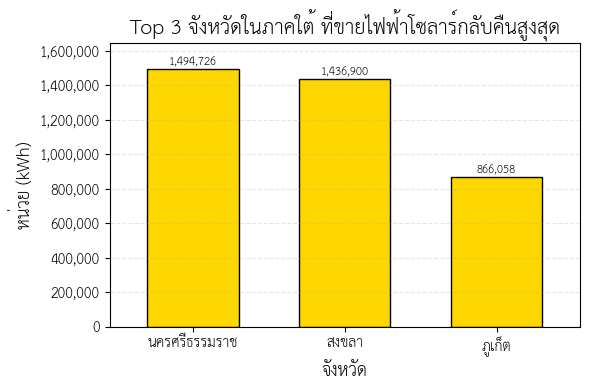

In [ ]:
# === กราฟ 10 จังหวัดขายไฟคืนมากที่สุด ===
top_sellers = df.groupby('จังหวัด')['ขายคืนรวมต่อปี'].sum().sort_values(ascending=False).head(10)
top_seller_provinces = top_sellers.index.tolist()
province_region_map = df.drop_duplicates(subset='จังหวัด').set_index('จังหวัด')['ภาค'].to_dict()
top_seller_regions = [province_region_map[prov] for prov in top_seller_provinces]
bar_colors = [region_colors[region] for region in top_seller_regions]
plt.figure(figsize=(8,5))
ax = top_sellers.plot(kind='bar', color=bar_colors, edgecolor='black')
plt.title('10 จังหวัดที่ขายไฟฟ้าโซลาร์กลับคืน PEA สูงสุด', fontsize=14, fontweight='bold')
plt.ylabel('หน่วย (kWh)', fontsize=12)
plt.xlabel('จังหวัด', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
# เพิ่มพื้นที่โล่งด้านบนแกน y
max_val = max(top_sellers)
ax.set_ylim(0, max_val*1.1)
# เพิ่ม grid
ax.grid(axis='y', linestyle='--', alpha=0.3)
# แสดงค่าบนแท่ง (fontsize=8)
for i, v in enumerate(top_sellers):
    plt.text(i, v + max_val*0.02, f'{v:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('10 จังหวัดที่ขายไฟฟ้าโซลาร์กลับคืน PEA สูงสุด.png', dpi=300, bbox_inches='tight')
plt.show()
# === 2. กราฟรวมรายภาค ===
top_sell_region = df.groupby('ภาค')['ขายคืนรวมต่อปี'].sum().sort_values(ascending=False)
colors_right = [region_colors[region] for region in top_sell_region.index]
plt.figure(figsize=(6,5))
ax = top_sell_region.plot(kind='bar', color=colors_right, edgecolor='black')
plt.title('ภาคที่ขายไฟฟ้าโซลาร์กลับคืน PEA สูงสุด', fontsize=16, fontweight='bold')
plt.xlabel('ภาค', fontsize=12)
plt.ylabel('หน่วย (kWh)', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
max_val = max(top_sell_region)
ax.set_ylim(0, max_val*1.1)
# เพิ่ม grid
ax.grid(axis='y', linestyle='--', alpha=0.3)
for i, v in enumerate(top_sell_region):
    plt.text(i, v + max_val*0.02, f'{v:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('ภาคที่ขายไฟฟ้าโซลาร์กลับคืน PEA สูงสุด.png', dpi=300, bbox_inches='tight')
plt.show()
# === 3. Top 3 จังหวัดในแต่ละภาค ===
regions = ['เหนือ', 'อีสาน', 'กลาง', 'ใต้']
for region in regions:
    df_region = df[df['ภาค'] == region]
    top3_provinces = df_region.groupby('จังหวัด')['ขายคืนรวมต่อปี'].sum().sort_values(ascending=False).head(3)
    plt.figure(figsize=(6,4))
    ax = top3_provinces.plot(kind='bar', color=region_colors[region], edgecolor='black', width=0.6)
    plt.title(f'Top 3 จังหวัดในภาค{region} ที่ขายไฟฟ้าโซลาร์กลับคืนสูงสุด', fontsize=14, fontweight='bold')
    plt.ylabel('หน่วย (kWh)', fontsize=12)
    plt.xlabel('จังหวัด', fontsize=12)
    plt.xticks(rotation=0, fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    max_val = max(top3_provinces)
    ax.set_ylim(0, max_val*1.1)  # เพิ่มพื้นที่โล่งด้านบน
    # เพิ่ม grid
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    # แสดงค่าบนแท่ง (fontsize=8)
    for i, v in enumerate(top3_provinces):
        plt.text(i, v + max_val*0.02, f'{v:,.0f}', ha='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(f"Top3_จังหวัดภาค{region}_ขายไฟฟ้าโซลาร์.png", dpi=300, bbox_inches='tight')
    plt.show()

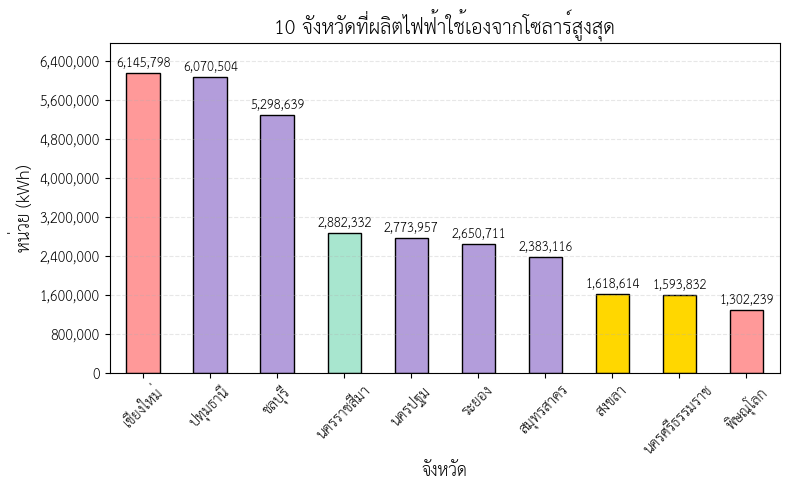

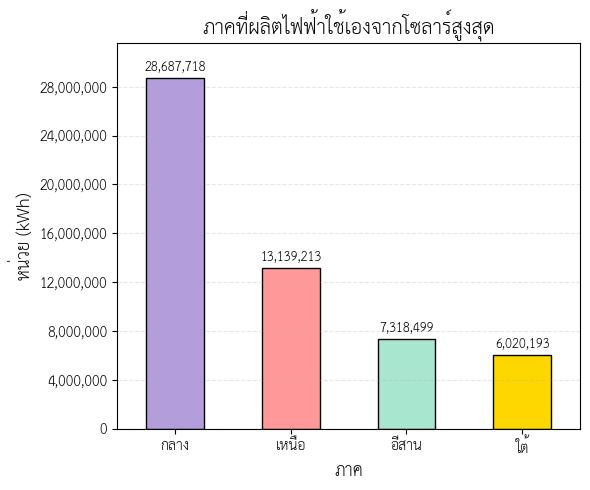

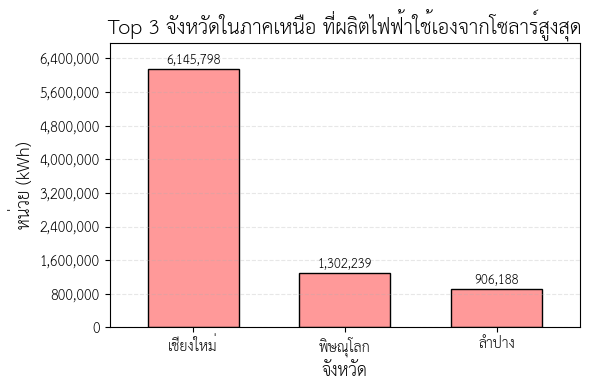

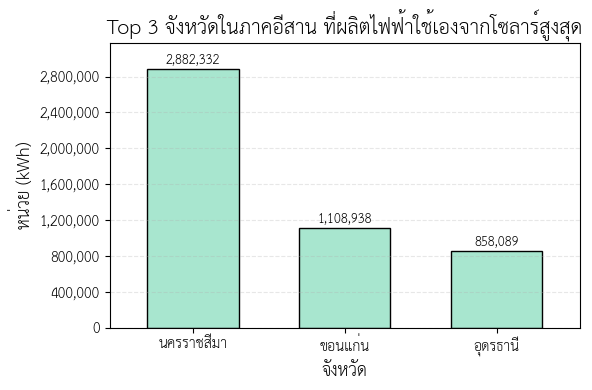

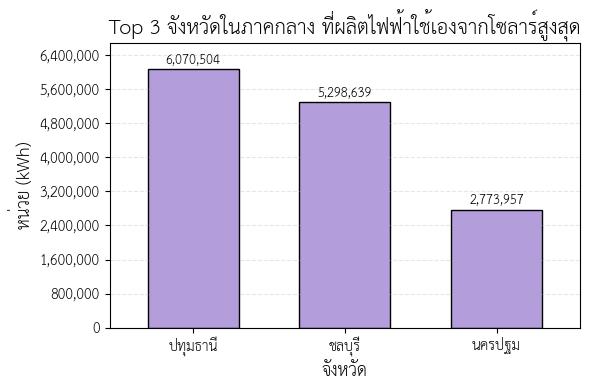

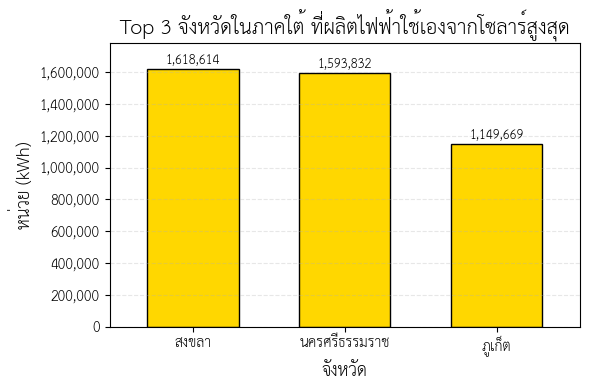

In [ ]:
# === 1) Top 10 จังหวัดที่ผลิตไฟฟ้าใช้เอง ===
top_selfuse = df.groupby('จังหวัด')['ใช้เองรวมต่อปี'].sum().sort_values(ascending=False).head(10)
bar_colors_selfuse = [region_colors[province_region_map[prov]] for prov in top_selfuse.index]
plt.figure(figsize=(8,5))
ax = top_selfuse.plot(kind='bar', color=bar_colors_selfuse, edgecolor='black')
plt.title('10 จังหวัดที่ผลิตไฟฟ้าใช้เองจากโซลาร์สูงสุด', fontsize=14, fontweight='bold')
plt.ylabel('หน่วย (kWh)', fontsize=12)
plt.xlabel('จังหวัด', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
# เพิ่มพื้นที่โล่งด้านบน
max_val = max(top_selfuse)
ax.set_ylim(0, max_val*1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
# แสดงค่าบนแท่ง
for i, v in enumerate(top_selfuse):
    ax.text(i, v + max_val*0.02, f'{v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('10 จังหวัดที่ผลิตไฟฟ้าใช้เองจากโซลาร์สูงสุด.png', dpi=300, bbox_inches='tight')
plt.show()
# === 2) Top ภาคที่ผลิตไฟฟ้าใช้เอง ===
top_selfuse_region = df.groupby('ภาค')['ใช้เองรวมต่อปี'].sum().sort_values(ascending=False)
colors_right_selfuse = [region_colors[region] for region in top_selfuse_region.index]
plt.figure(figsize=(6,5))
ax = top_selfuse_region.plot(kind='bar', color=colors_right_selfuse, edgecolor='black')
plt.title('ภาคที่ผลิตไฟฟ้าใช้เองจากโซลาร์สูงสุด', fontsize=14, fontweight='bold')
plt.ylabel('หน่วย (kWh)', fontsize=12)
plt.xlabel('ภาค', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
max_val = max(top_selfuse_region)
ax.set_ylim(0, max_val*1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
for i, v in enumerate(top_selfuse_region):
    ax.text(i, v + max_val*0.02, f'{v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('ภาคที่ผลิตไฟฟ้าใช้เองจากโซลาร์สูงสุด.png', dpi=300, bbox_inches='tight')
plt.show()
# === 3-6) Top 3 จังหวัดในแต่ละภาค ===
regions = ['เหนือ', 'อีสาน', 'กลาง', 'ใต้']
for region in regions:
    df_region = df[df['ภาค'] == region]
    top3_provinces = (
        df_region.groupby('จังหวัด')['ใช้เองรวมต่อปี']
        .sum()
        .sort_values(ascending=False)
        .head(3)
    )
    plt.figure(figsize=(6,4))
    ax = top3_provinces.plot(kind='bar',
                             color=region_colors[region],
                             edgecolor='black',
                             width=0.6)
    plt.title(f'Top 3 จังหวัดในภาค{region} ที่ผลิตไฟฟ้าใช้เองจากโซลาร์สูงสุด', fontsize=14, fontweight='bold')
    plt.ylabel('หน่วย (kWh)', fontsize=12)
    plt.xlabel('จังหวัด', fontsize=12)
    plt.xticks(rotation=0, fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    max_val = max(top3_provinces)
    ax.set_ylim(0, max_val*1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    for i, v in enumerate(top3_provinces):
        ax.text(i, v + max_val*0.02, f'{v:,.0f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(f"Top 3 จังหวัดในภาค{region} ที่ผลิตไฟฟ้าใช้เองจากโซลาร์สูงสุด.png", dpi=300, bbox_inches='tight')
    plt.show()

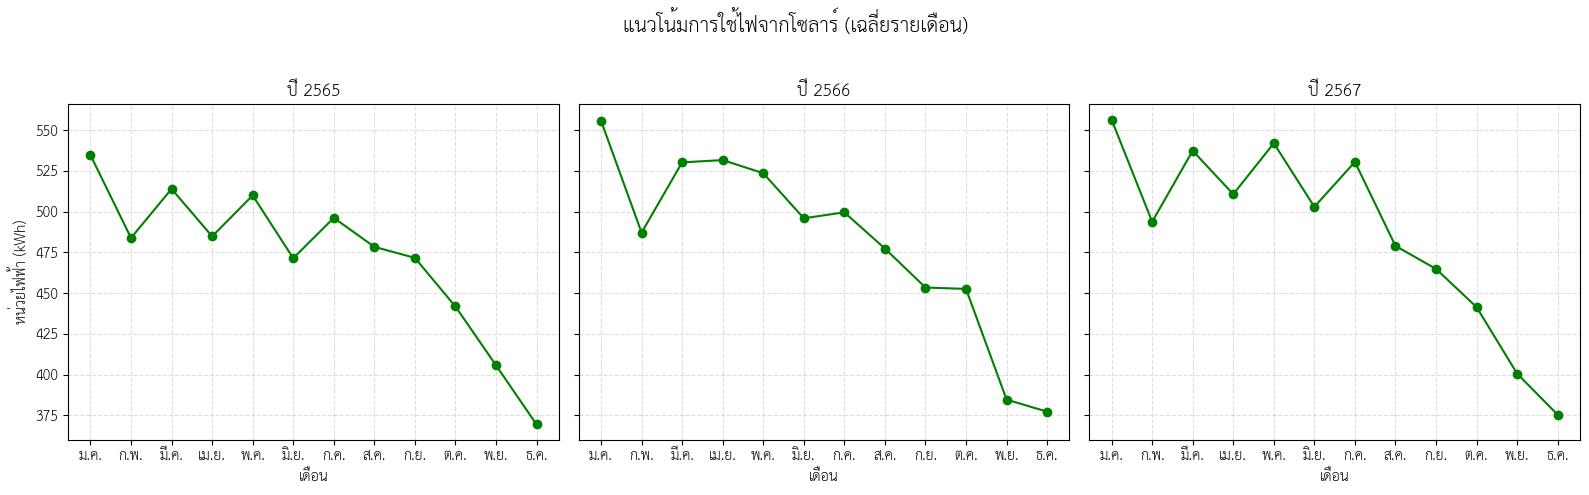

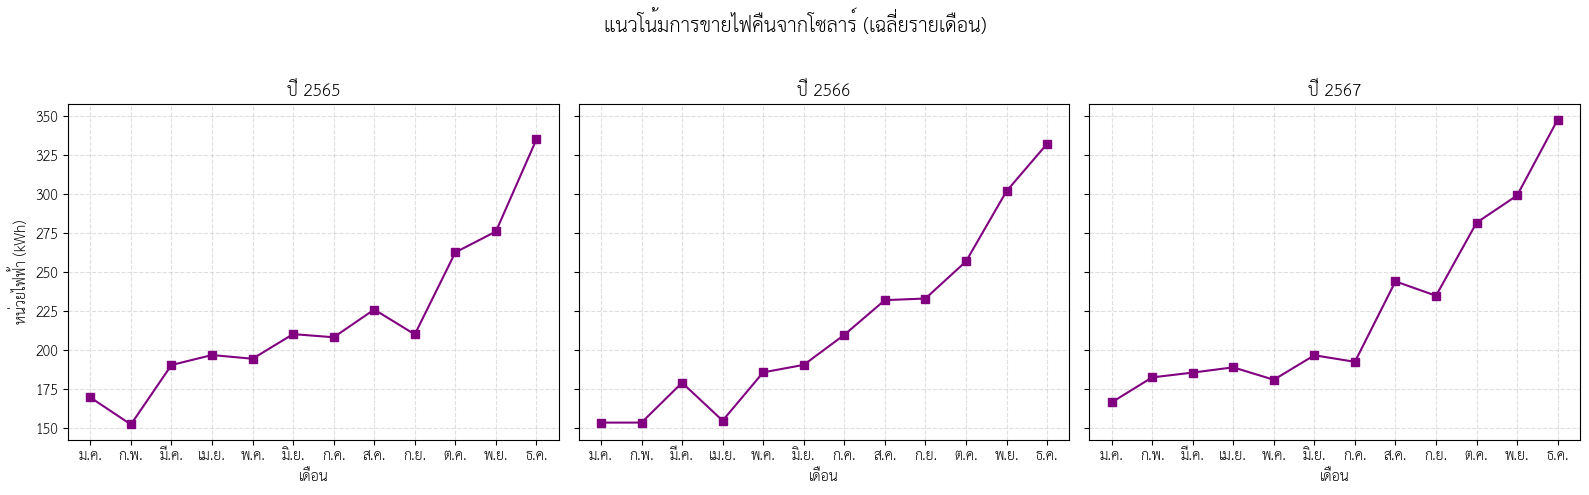

In [ ]:
# === เตรียมข้อมูลพื้นฐาน ===
years = sorted(df['ปี'].unique())
months_order = ['ม.ค.', 'ก.พ.', 'มี.ค.', 'เม.ย.', 'พ.ค.', 'มิ.ย.',
                'ก.ค.', 'ส.ค.', 'ก.ย.', 'ต.ค.', 'พ.ย.', 'ธ.ค.']
# === กำหนดคอลัมน์เฉพาะของแต่ละกราฟ ===
col_type_map = {
    'ใช้เองจากโซลาร์': [col for col in df.columns if 'ใช้เอง' in col],
    'ขายคืนรวม': [col for col in df.columns if 'ขายคืนรวม' in col]
}
# === วาดกราฟแยกตามประเภท ===
for title, cols in col_type_map.items():
    # สร้าง mapping เดือน → คอลัมน์
    month_map = {m: col for m in months_order for col in cols if m in col}
    # สร้าง subplot รายปี
    fig, axes = plt.subplots(1, len(years), figsize=(16, 5), sharey=True)
    for i, year in enumerate(years):
        df_year = df[df['ปี'] == year]
        monthly_avg = [df_year[month_map[m]].mean() if m in month_map else 0 for m in months_order]
        axes[i].plot(months_order, monthly_avg, marker='o' if title == 'ใช้เองจากโซลาร์' else 's',
                     color='green' if title == 'ใช้เองจากโซลาร์' else 'purple')
        axes[i].set_title(f'ปี {year}')
        axes[i].set_xlabel('เดือน')
        if i == 0:
            axes[i].set_ylabel('หน่วยไฟฟ้า (kWh)')
        axes[i].grid(True, linestyle='--', alpha=0.4)
    # ตั้งชื่อหัวข้อของกราฟ
    plt.suptitle(f'แนวโน้มการ{"ใช้ไฟจากโซลาร์" if title == "ใช้เองจากโซลาร์" else "ขายไฟคืนจากโซลาร์"} (เฉลี่ยรายเดือน)', fontsize=14, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"แนวโน้มการ{"ใช้ไฟจากโซลาร์" if title == "ใช้เองจากโซลาร์" else "ขายไฟคืนจากโซลาร์"} (เฉลี่ยรายเดือน).png", dpi=300, bbox_inches='tight')
    plt.show()

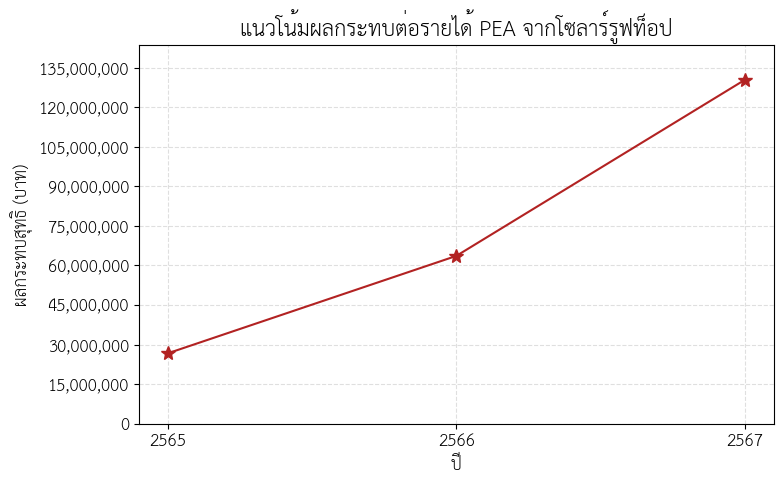

<Figure size 800x500 with 0 Axes>

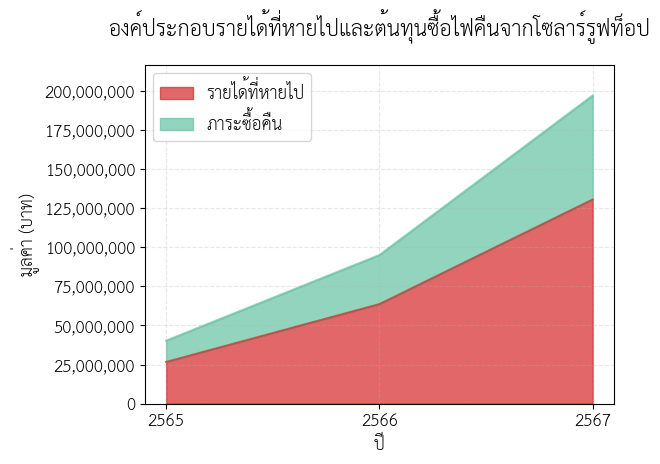

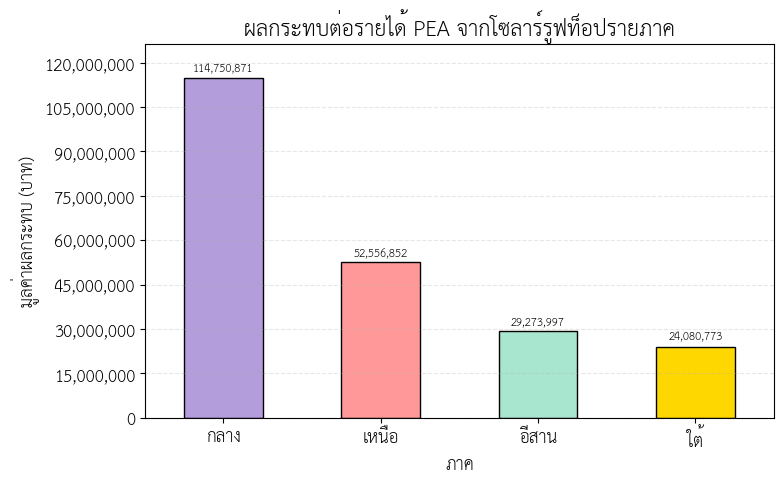

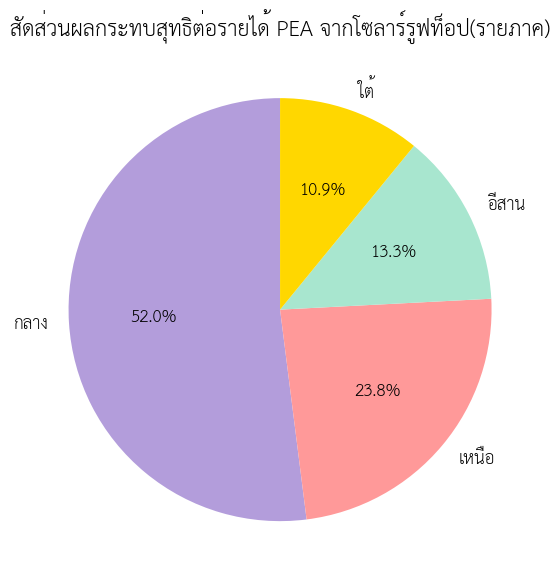

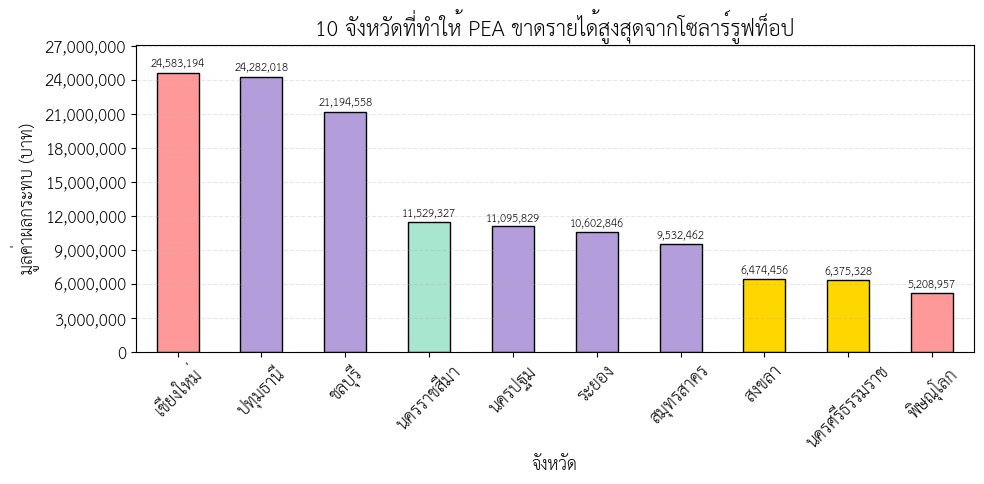

In [ ]:
plt.rcParams.update({'font.size': 12})
# ------------------ กราฟ 1: แนวโน้มผลกระทบรายปี (Line) ------------------
plt.rcParams.update({'font.size': 12})
impact_by_year = df.groupby('ปี')['รายได้ที่หายไป'].sum()
plt.figure(figsize=(8, 5))
ax1 = impact_by_year.plot(kind='line', marker='*', color='firebrick', markersize=10)
plt.title('แนวโน้มผลกระทบต่อรายได้ PEA จากโซลาร์รูฟท็อป', fontsize=15, fontweight='bold')
plt.xlabel('ปี', fontsize=12)
plt.ylabel('ผลกระทบสุทธิ (บาท)', fontsize=12)
plt.xticks(impact_by_year.index, impact_by_year.index.astype(int))
plt.grid(True, linestyle='--', alpha=0.4)
ax1.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
max_y = max(impact_by_year)
ax1.set_ylim(0, max_y*1.1)
plt.tight_layout()
plt.savefig('แนวโน้มผลกระทบต่อรายได้ PEA จากโซลาร์รูฟท็อป.png', dpi=300, bbox_inches='tight')
plt.show()
# ------------------ กราฟ 2: Stacked Area ------------------
impact = df.groupby('ปี')[['รายได้ที่หายไป', 'ภาระซื้อคืน']].sum()
plt.figure(figsize=(8, 5))
ax2 = impact.plot(kind='area', stacked=True, alpha=0.7, color=['#D62728', '#66C2A5'])
plt.title('องค์ประกอบรายได้ที่หายไปและต้นทุนซื้อไฟคืนจากโซลาร์รูฟท็อป',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('ปี', fontsize=12)
plt.ylabel('มูลค่า (บาท)', fontsize=12)
plt.xticks(impact.index, impact.index.astype(int))
plt.grid(True, linestyle='--', alpha=0.3)
plt.margins(x=0.05)  # เว้นขอบซ้ายขวาเล็กน้อย
# --- ตั้งค่าแกน y ให้เป็นจำนวนเต็มและมีลูกน้ำ ---
ax2.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.set_ylim(0, max(impact.sum(axis=1))*1.1)
plt.tight_layout()
plt.savefig('องค์ประกอบรายได้ที่หายไปและต้นทุนซื้อไฟคืนจากโซลาร์รูฟท็อป.png', dpi=300, bbox_inches='tight')
plt.show()
# ------------------ กราฟ 3: Bar รายภาค ------------------
lost_by_region = df.groupby('ภาค')['รายได้ที่หายไป'].sum().sort_values(ascending=False)
region_bar_colors = [region_colors.get(region, '#BBBBBB') for region in lost_by_region.index]
plt.figure(figsize=(8, 5))
ax3 = lost_by_region.plot(kind='bar', color=region_bar_colors, edgecolor='black')
plt.title('ผลกระทบต่อรายได้ PEA จากโซลาร์รูฟท็อปรายภาค', fontsize=15, fontweight='bold')
plt.ylabel('มูลค่าผลกระทบ (บาท)', fontsize=12)
plt.xlabel('ภาค', fontsize=12)
plt.xticks(range(len(lost_by_region.index)), lost_by_region.index, rotation=0)
plt.margins(x=0.05)
ax3.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax3.set_ylim(0, max(lost_by_region)*1.1)
ax3.grid(axis='y', linestyle='--', alpha=0.3)
for i, v in enumerate(lost_by_region):
    ax3.text(i, v + max(lost_by_region)*0.02, f'{v:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('ผลกระทบต่อรายได้ PEA จากโซลาร์รูฟท็อปรายภาค.png', dpi=300, bbox_inches='tight')
plt.show()
# ------------------ กราฟ 4: Pie รายภาค ------------------
plt.figure(figsize=(6, 6))
lost_by_region.plot(kind='pie',
                    autopct='%1.1f%%',
                    startangle=90,
                    colors=region_bar_colors)
plt.ylabel('')
plt.title('สัดส่วนผลกระทบสุทธิต่อรายได้ PEA จากโซลาร์รูฟท็อป(รายภาค)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('สัดส่วนผลกระทบสุทธิต่อรายได้ PEA จากโซลาร์รูฟท็อป(รายภาค).png', dpi=300, bbox_inches='tight')
plt.show()
# ------------------ กราฟ 5: Top 10 จังหวัด ------------------
lost_by_province = df.groupby('จังหวัด')['รายได้ที่หายไป'].sum().sort_values(ascending=False).head(10)
top10_provinces = lost_by_province.index
province_to_region = df.drop_duplicates(subset=['จังหวัด'])[['จังหวัด', 'ภาค']].set_index('จังหวัด')['ภาค'].to_dict()
colors = [region_colors.get(province_to_region.get(prov, ''), 'gray') for prov in top10_provinces]
plt.figure(figsize=(10, 5))
ax5 = lost_by_province.plot(kind='bar', color=colors, edgecolor='black')
plt.title('10 จังหวัดที่ทำให้ PEA ขาดรายได้สูงสุดจากโซลาร์รูฟท็อป', fontsize=15, fontweight='bold')
plt.ylabel('มูลค่าผลกระทบ (บาท)', fontsize=12)
plt.xticks(range(len(top10_provinces)), top10_provinces, rotation=45)
plt.margins(x=0.05)
ax5.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax5.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax5.set_ylim(0, max(lost_by_province)*1.1)
ax5.grid(axis='y', linestyle='--', alpha=0.3)
for i, v in enumerate(lost_by_province):
    ax5.text(i, v + max(lost_by_province)*0.02, f'{v:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('10 จังหวัดที่ทำให้ PEA ขาดรายได้สูงสุดจากโซลาร์รูฟท็อป.png', dpi=300, bbox_inches='tight')
plt.show()


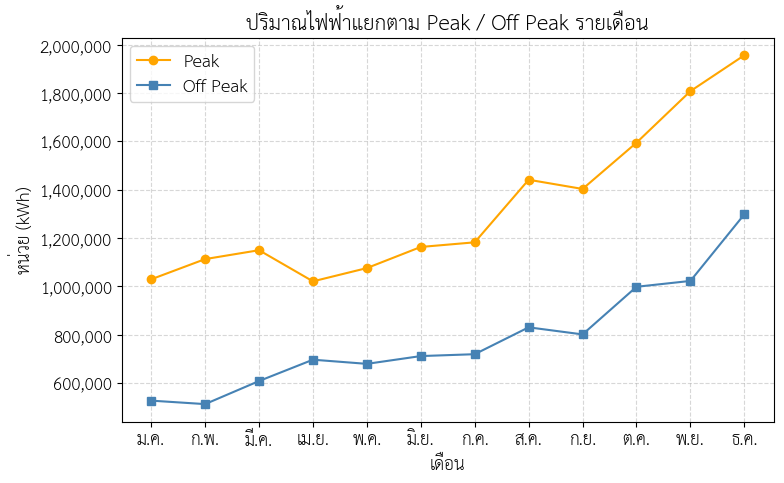

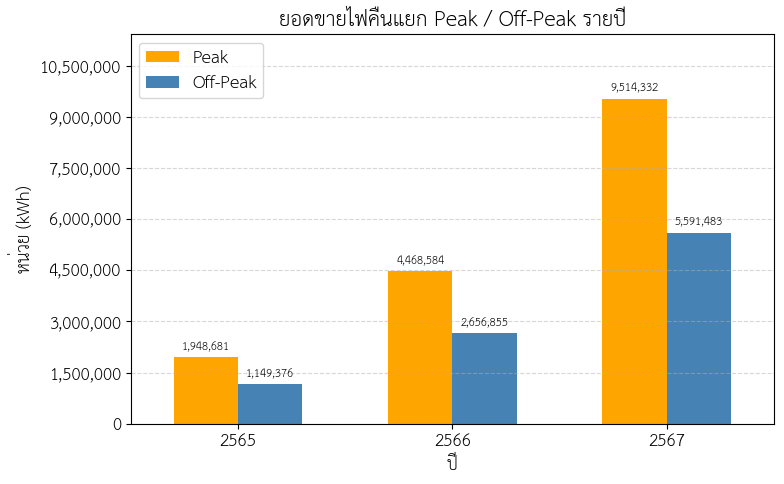

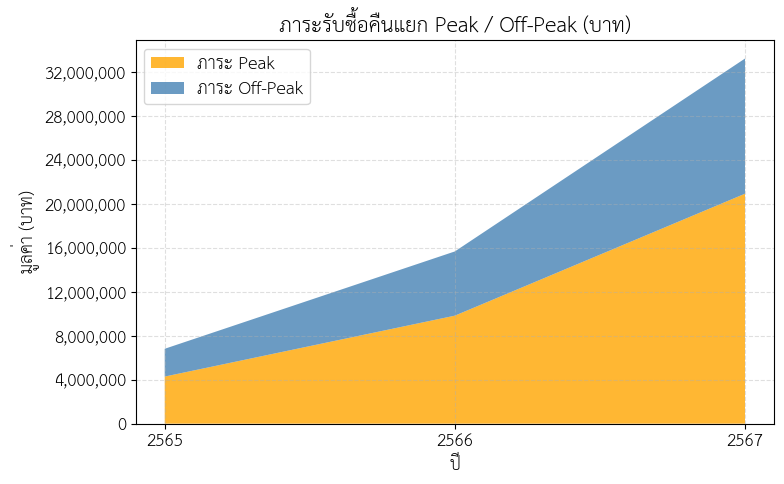

In [ ]:
months_order = ['ม.ค.', 'ก.พ.', 'มี.ค.', 'เม.ย.', 'พ.ค.', 'มิ.ย.',
                'ก.ค.', 'ส.ค.', 'ก.ย.', 'ต.ค.', 'พ.ย.', 'ธ.ค.']
# --- เตรียมคอลัมน์ ---
peak_cols = [f"{m} peak" for m in months_order]
offpeak_cols = [f"{m} off peak" for m in months_order]
# --- ตรวจสอบคอลัมน์ที่ขาด ---
missing_cols = [col for col in peak_cols + offpeak_cols if col not in df.columns]
if missing_cols:
    print("Missing columns:", missing_cols)
# --- เตรียมข้อมูล ---
peak_sum = df[peak_cols].sum()
offpeak_sum = df[offpeak_cols].sum()
years = sorted(df['ปี'].unique())
peak_year_sum = []
offpeak_year_sum = []
impact_peak = []
impact_offpeak = []
price = 2.20
for year in years:
    df_y = df[df['ปี'] == year]
    peak_val = df_y[peak_cols].sum().sum()
    offpeak_val = df_y[offpeak_cols].sum().sum()
    peak_year_sum.append(peak_val)
    offpeak_year_sum.append(offpeak_val)
    impact_peak.append(peak_val * price)
    impact_offpeak.append(offpeak_val * price)
def y_formatter(x, pos):
    return f'{int(x):,}'
# กราฟที่ 1: ปริมาณไฟฟ้า Peak/Off-Peak รายเดือน
plt.figure(figsize=(8,5))
plt.plot(months_order, peak_sum.values, label='Peak', marker='o', color='orange')
plt.plot(months_order, offpeak_sum.values, label='Off Peak', marker='s', color='steelblue')
plt.title('ปริมาณไฟฟ้าแยกตาม Peak / Off Peak รายเดือน')
plt.xlabel('เดือน')
plt.ylabel('หน่วย (kWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.gca().yaxis.set_major_formatter(FuncFormatter(y_formatter))
plt.tight_layout()
plt.savefig('ปริมาณไฟฟ้าแยกตาม Peak Off Peak รายเดือน.png', dpi=300, bbox_inches='tight')
plt.show()
# กราฟที่ 2: ยอดขายไฟคืน Peak/Off-Peak รายปี (แก้ width & top margin)
x = np.arange(len(years))
bar_width = 0.3  # ลดความกว้างของแท่ง
plt.figure(figsize=(8,5))
bars_peak = plt.bar(x - bar_width/2, peak_year_sum, width=bar_width, label='Peak', color='orange')
bars_offpeak = plt.bar(x + bar_width/2, offpeak_year_sum, width=bar_width, label='Off-Peak', color='steelblue')
ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels([str(int(y)) for y in years])
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(FuncFormatter(y_formatter))
ax.set_xlim(-0.5, len(years)-0.5)  # margin ซ้ายขวาไม่ชิดขอบ
top_ylim = max(max(peak_year_sum), max(offpeak_year_sum)) * 1.2
ax.set_ylim(0, top_ylim)
# แสดงตัวเลขบนแท่ง
for bar in bars_peak:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + top_ylim*0.02,
            f'{int(height):,}', ha='center', fontsize=8)
for bar in bars_offpeak:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + top_ylim*0.02,
            f'{int(height):,}', ha='center', fontsize=8)
plt.title('ยอดขายไฟคืนแยก Peak / Off-Peak รายปี')
plt.xlabel('ปี')
plt.ylabel('หน่วย (kWh)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ยอดขายไฟคืนแยก Peak Off-Peak รายปี.png', dpi=300, bbox_inches='tight')
plt.show()
# กราฟที่ 3: ภาระรับซื้อคืน Peak/Off-Peak (บาท)
plt.figure(figsize=(8,5))
plt.stackplot(x, impact_peak, impact_offpeak, labels=['ภาระ Peak', 'ภาระ Off-Peak'],
              colors=['orange','steelblue'], alpha=0.8)
ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels([str(int(y)) for y in years])
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(FuncFormatter(y_formatter))
plt.title('ภาระรับซื้อคืนแยก Peak / Off-Peak (บาท)')
plt.xlabel('ปี')
plt.ylabel('มูลค่า (บาท)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ภาระรับซื้อคืนแยก Peak Off-Peak (บาท).png', dpi=300, bbox_inches='tight')
plt.show()

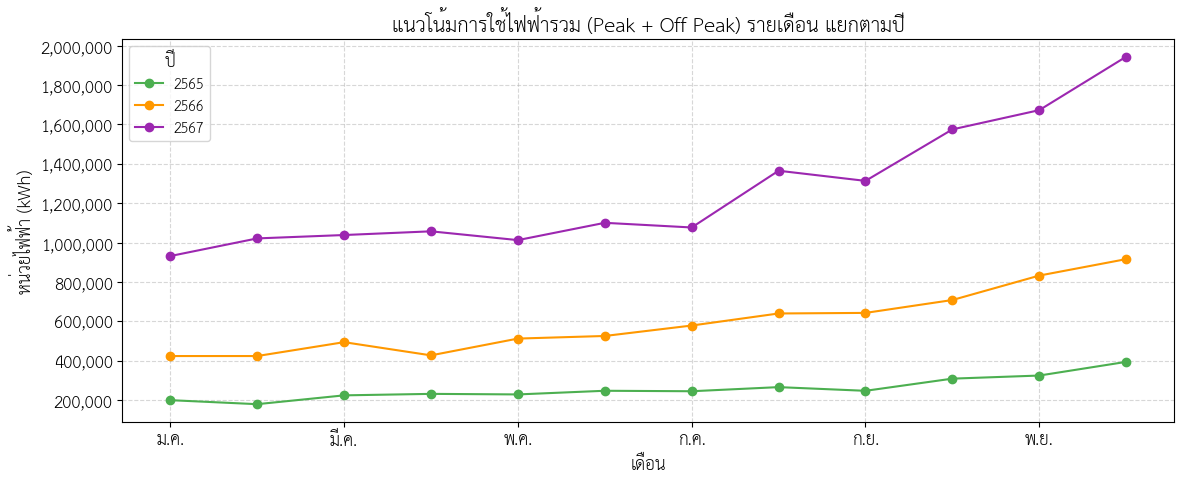

In [ ]:
# รวม Peak + Off-Peak ต่อเดือน สำหรับแต่ละปี
monthly_data = {}
for year in sorted(df['ปี'].unique()):
    monthly_totals = []
    for month in months_order:
        peak_col = f"{month} peak"
        offpeak_col = f"{month} off peak"
        total = df[df['ปี'] == year][[peak_col, offpeak_col]].sum().sum()
        monthly_totals.append(total)
    monthly_data[str(int(year))] = monthly_totals
monthly_df = pd.DataFrame(monthly_data, index=months_order)
custom_colors = ['#4CAF50', '#FF9800', '#9C27B0', '#795548', '#607D8B', '#8BC34A', '#FFC107', '#FF5722']
ax = monthly_df.plot(
    kind='line',
    marker='o',
    color=custom_colors[:monthly_df.shape[1]],
    figsize=(12, 5)
)
plt.title('แนวโน้มการใช้ไฟฟ้ารวม (Peak + Off Peak) รายเดือน แยกตามปี', fontsize=14, weight='bold')
plt.xlabel('เดือน', fontsize=12)
plt.ylabel('หน่วยไฟฟ้า (kWh)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='ปี', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('แนวโน้มการใช้ไฟฟ้ารวมPeak Off Peak รายเดือน แยกตามปี.png', dpi=300, bbox_inches='tight')
plt.show()

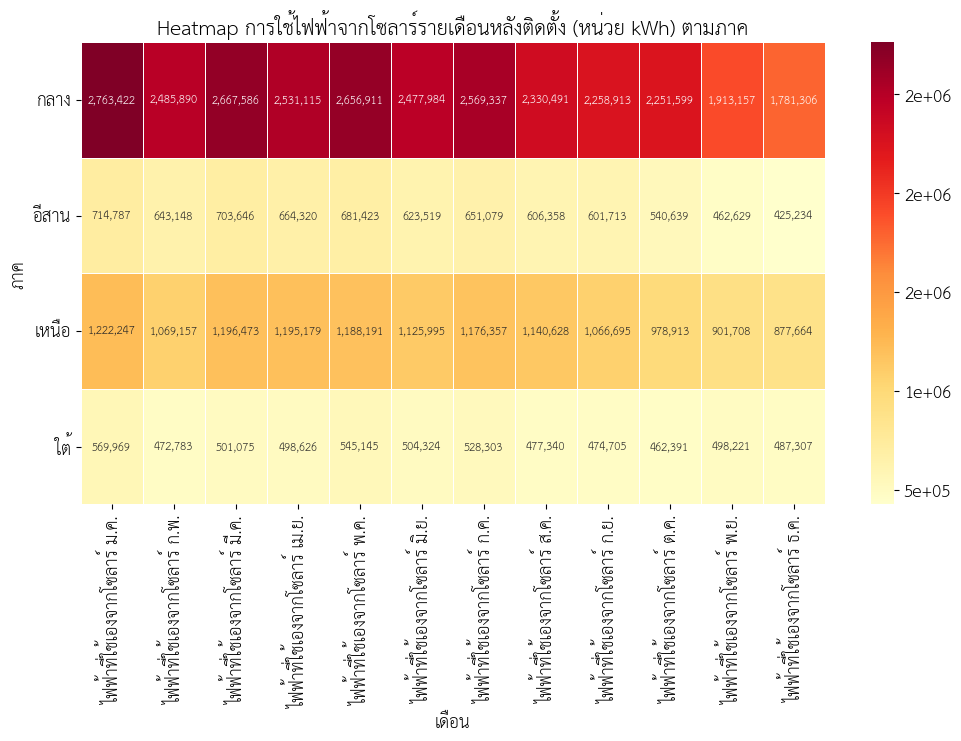

In [ ]:
month_cols = [
    'ไฟฟ้าที่ใช้เองจากโซลาร์ ม.ค.', 'ไฟฟ้าที่ใช้เองจากโซลาร์ ก.พ.', 'ไฟฟ้าที่ใช้เองจากโซลาร์ มี.ค.',
    'ไฟฟ้าที่ใช้เองจากโซลาร์ เม.ย.', 'ไฟฟ้าที่ใช้เองจากโซลาร์ พ.ค.', 'ไฟฟ้าที่ใช้เองจากโซลาร์ มิ.ย.',
    'ไฟฟ้าที่ใช้เองจากโซลาร์ ก.ค.', 'ไฟฟ้าที่ใช้เองจากโซลาร์ ส.ค.', 'ไฟฟ้าที่ใช้เองจากโซลาร์ ก.ย.',
    'ไฟฟ้าที่ใช้เองจากโซลาร์ ต.ค.', 'ไฟฟ้าที่ใช้เองจากโซลาร์ พ.ย.', 'ไฟฟ้าที่ใช้เองจากโซลาร์ ธ.ค.'
]
df_grouped = df.groupby('ภาค')[month_cols].sum()
def fmt_with_comma(x):
    return f"{int(x):,}"
plt.figure(figsize=(12, 6))
sns.heatmap(
    df_grouped,
    annot=True,
    fmt="",  # ปิดการ format default
    cmap="YlOrRd",
    linewidths=.5,
    annot_kws={"size": 8},
    cbar_kws={'format': '%.0e'}  # ให้ scale bar ชัดขึ้น
)
for t in plt.gca().texts:
    t.set_text(fmt_with_comma(float(t.get_text())))
plt.title("Heatmap การใช้ไฟฟ้าจากโซลาร์รายเดือนหลังติดตั้ง (หน่วย kWh) ตามภาค", fontsize=14)
plt.xlabel("เดือน")
plt.ylabel("ภาค")
plt.yticks(rotation=0)
plt.savefig('Heatmap8.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# กรองข้อมูลเฉพาะปี 2567
df_2567 = df[df['ปี'] == 2567]
# สรุปจำนวนหลังและกำลังการผลิตเฉลี่ยต่อหลังของแต่ละภาค
summary = df_2567.groupby('ภาค').agg(
    จำนวนหลัง=('กำลังการผลิตติดตั้ง(kwh)', 'count'),
    กำลังการผลิตเฉลี่ยต่อหลัง=('กำลังการผลิตติดตั้ง(kwh)', 'mean')
).reset_index()
# แสดงผล
print(summary)


     ภาค  จํานวนหลัง  กําลังการผลิตเฉลี่ยต่อหลัง
0   กลาง        2976                    5.285151
1  อีสาน         808                    5.276761
2  เหนือ        1274                    5.625243
3    ใต้         530                    5.693698


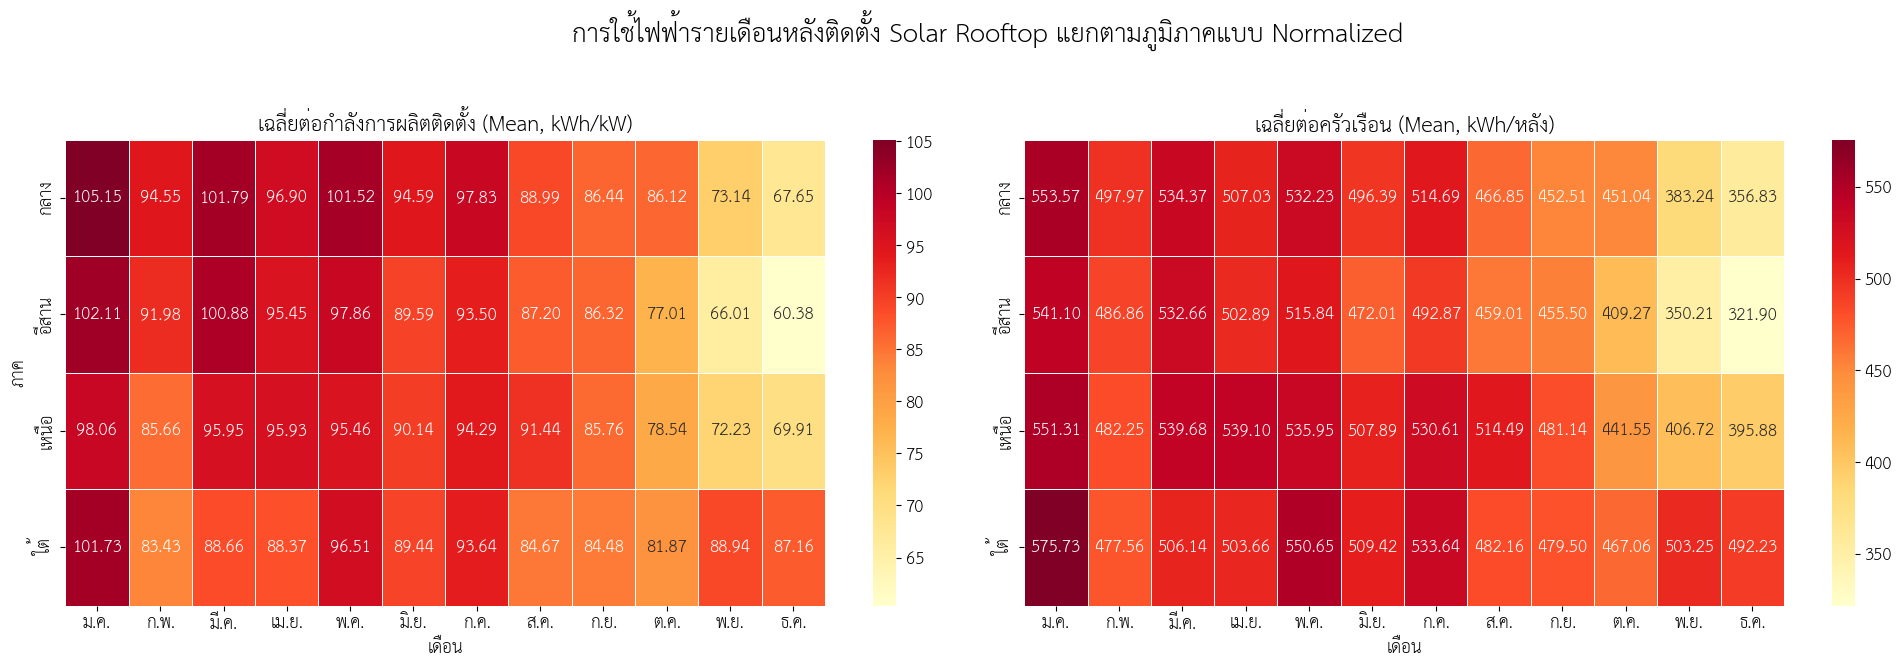

In [ ]:
months = ['ม.ค.', 'ก.พ.', 'มี.ค.', 'เม.ย.', 'พ.ค.', 'มิ.ย.',
          'ก.ค.', 'ส.ค.', 'ก.ย.', 'ต.ค.', 'พ.ย.', 'ธ.ค.']
regions = sorted(df['ภาค'].unique())
heatmap_mean_per_kwh = pd.DataFrame(index=regions, columns=months, dtype=float)
heatmap_mean_per_install = pd.DataFrame(index=regions, columns=months, dtype=float)
heatmap_median_per_kwh = pd.DataFrame(index=regions, columns=months, dtype=float)
heatmap_median_per_install = pd.DataFrame(index=regions, columns=months, dtype=float)
# คำนวณ
for month in months:
    # ต่อกำลังการผลิตติดตั้ง
    per_kwh = (df[f'ไฟฟ้าที่ใช้เองจากโซลาร์ {month}'] / df['กำลังการผลิตติดตั้ง(kwh)']) \
                .replace([np.inf, -np.inf], np.nan)
    df[f'per_kwh_capacity_{month}'] = per_kwh

    heatmap_mean_per_kwh[month] = df.groupby('ภาค')[f'per_kwh_capacity_{month}'].mean()
    heatmap_median_per_kwh[month] = df.groupby('ภาค')[f'per_kwh_capacity_{month}'].median()
    # ต่อผู้ติดตั้ง
    per_install = df[f'ไฟฟ้าที่ใช้เองจากโซลาร์ {month}']
    heatmap_mean_per_install[month] = df.groupby('ภาค')[per_install.name].mean()
    heatmap_median_per_install[month] = df.groupby('ภาค')[per_install.name].median()
# ===== Heatmap (Mean เท่านั้น) =====
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('การใช้ไฟฟ้ารายเดือนหลังติดตั้ง Solar Rooftop แยกตามภูมิภาคแบบ Normalized ', fontsize=18)
sns.heatmap(heatmap_mean_per_kwh, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=.5, ax=axes[0])
axes[0].set_title('เฉลี่ยต่อกำลังการผลิตติดตั้ง (Mean, kWh/kW)')
axes[0].set_xlabel('เดือน'); axes[0].set_ylabel('ภาค')
sns.heatmap(heatmap_mean_per_install, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=.5, ax=axes[1])
axes[1].set_title('เฉลี่ยต่อครัวเรือน (Mean, kWh/หลัง)')
axes[1].set_xlabel('เดือน'); axes[1].set_ylabel('')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Heatmapการใช้ไฟฟ้าจากโซลาร์รายเดือนหลังติดตั้งตามภาค.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# จัดกลุ่มและรวมข้อมูล
df_grouped = (
    df.groupby(["ปี", "ภาค"])[["ขายคืนรวมต่อปี", "ใช้เองรวมต่อปี"]]
    .sum()
    .reset_index()
)


# ถ้าใช้ Jupyter Notebook หรือ Google Colab
from IPython.display import display
display(df_grouped)


,ปี,ภาค,ขายคืนรวมต่อปี,ใช้เองรวมต่อปี
0,2565,กลาง,2781184,3.167499e+06
1,2565,อีสาน,852956,7.083252e+05
2,2565,เหนือ,1956234,1.897004e+06
3,2565,ใต้,605740,8.856745e+05
4,2566,กลาง,7010440,8.282381e+06
5,2566,อีสาน,1950684,2.115166e+06
6,2566,เหนือ,3679158,3.515470e+06
7,2566,ใต้,1610596,1.987325e+06
8,2567,กลาง,15261964,1.723784e+07
9,2567,อีสาน,4494384,4.495008e+06


In [ ]:
# สร้างคอลัมน์กำไร/ขาดกำไรจากข้อมูลหน่วยไฟฟ้า
df["กำไรจากไฟขายคืน (บาท)"] = df["ขายคืนรวมต่อปี"] * 0.80
df["ขาดกำไรจากการใช้เอง (บาท)"] = df["ใช้เองรวมต่อปี"] * 0.80

# จัดกลุ่มและรวมข้อมูล
df_profit_grouped = (
    df.groupby(["ปี", "ภาค"])[["กำไรจากไฟขายคืน (บาท)", "ขาดกำไรจากการใช้เอง (บาท)"]]
    .sum()
    .reset_index()
)

# แสดงผล
from IPython.display import display
display(df_profit_grouped)


,ปี,ภาค,กำไรจากไฟขายคืน (บาท),ขาดกำไรจากการใช้เอง (บาท)
0,2565,กลาง,2224947.2,2.533999e+06
1,2565,อีสาน,682364.8,5.666602e+05
2,2565,เหนือ,1564987.2,1.517603e+06
3,2565,ใต้,484592.0,7.085396e+05
4,2566,กลาง,5608352.0,6.625905e+06
5,2566,อีสาน,1560547.2,1.692133e+06
6,2566,เหนือ,2943326.4,2.812376e+06
7,2566,ใต้,1288476.8,1.589860e+06
8,2567,กลาง,12209571.2,1.379027e+07
9,2567,อีสาน,3595507.2,3.596006e+06


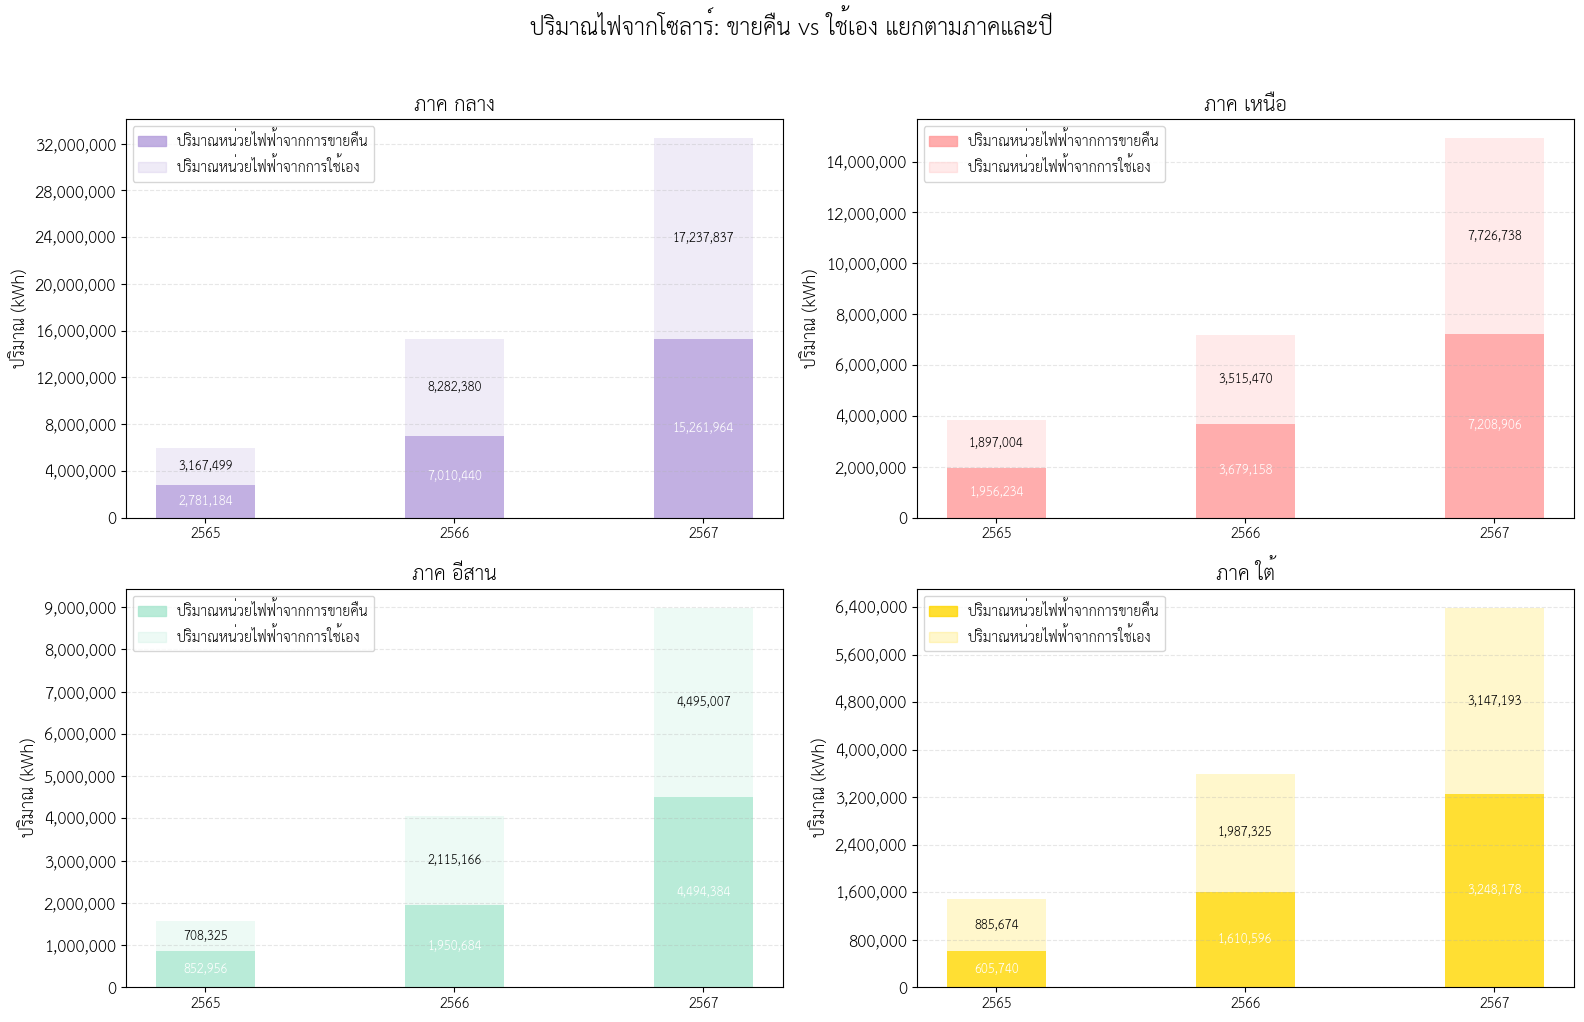

In [ ]:
# --- ใช้ข้อมูลจาก df_grouped โดยตรง ---
data = df_grouped.copy()
years = sorted(data["ปี"].unique())

# ✅ จัดเรียงภาคตามปริมาณรวม (ขายคืน+ใช้เอง) จากมากไปน้อย
region_totals = (
    data.groupby("ภาค")[["ขายคืนรวมต่อปี", "ใช้เองรวมต่อปี"]]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)
regions = region_totals.index.tolist()

x = np.arange(len(years))
width = 0.4  # ความกว้างแท่ง

color_sold_alpha = 0.8
color_self_alpha = 0.2

# --- สร้าง subplots 4 กราฟ ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='white')
axes = axes.flatten()

# หัวข้อหลักของกราฟ
fig.suptitle("ปริมาณไฟจากโซลาร์: ขายคืน vs ใช้เอง แยกตามภาคและปี",
             fontsize=16, fontweight="bold", y=1.02)

for idx, region in enumerate(regions):
    ax = axes[idx]
    ax.set_facecolor("white")

    # ดึงข้อมูลเฉพาะภาคและเรียงตามปี
    subset = data[data["ภาค"] == region].sort_values("ปี")
    sold_vals = subset["ขายคืนรวมต่อปี"].values
    self_vals = subset["ใช้เองรวมต่อปี"].values

    # Plot ขายคืน
    ax.bar(x, sold_vals, width=width,
           color=mcolors.to_rgba(region_colors[region], alpha=color_sold_alpha))
    # Plot ใช้เอง (stacked บนขายคืน)
    ax.bar(x, self_vals, width=width, bottom=sold_vals,
           color=mcolors.to_rgba(region_colors[region], alpha=color_self_alpha))

    # แกนและกริด
    ax.set_title(f"ภาค {region}", fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(years, fontsize=10)
    ax.set_ylabel("ปริมาณ (kWh)", fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))

    # ใส่ตัวเลขบนแท่ง
    for xi, (sold, self_use) in enumerate(zip(sold_vals, self_vals)):
        ax.text(xi, sold/2, f"{int(sold):,}", ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')
        ax.text(xi, sold + self_use/2, f"{int(self_use):,}", ha='center', va='center',
                fontsize=9, color='black', fontweight='bold')

    # legend
    sold_patch = plt.Rectangle((0,0),1,1,
                               color=mcolors.to_rgba(region_colors[region], alpha=color_sold_alpha))
    self_patch = plt.Rectangle((0,0),1,1,
                               color=mcolors.to_rgba(region_colors[region], alpha=color_self_alpha))
    ax.legend([sold_patch, self_patch],
              ["ปริมาณหน่วยไฟฟ้าจากการขายคืน", "ปริมาณหน่วยไฟฟ้าจากการใช้เอง"],
              loc='upper left', fontsize=10)

plt.tight_layout()
fig.savefig("หน่วยไฟฟ้าใหม่.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


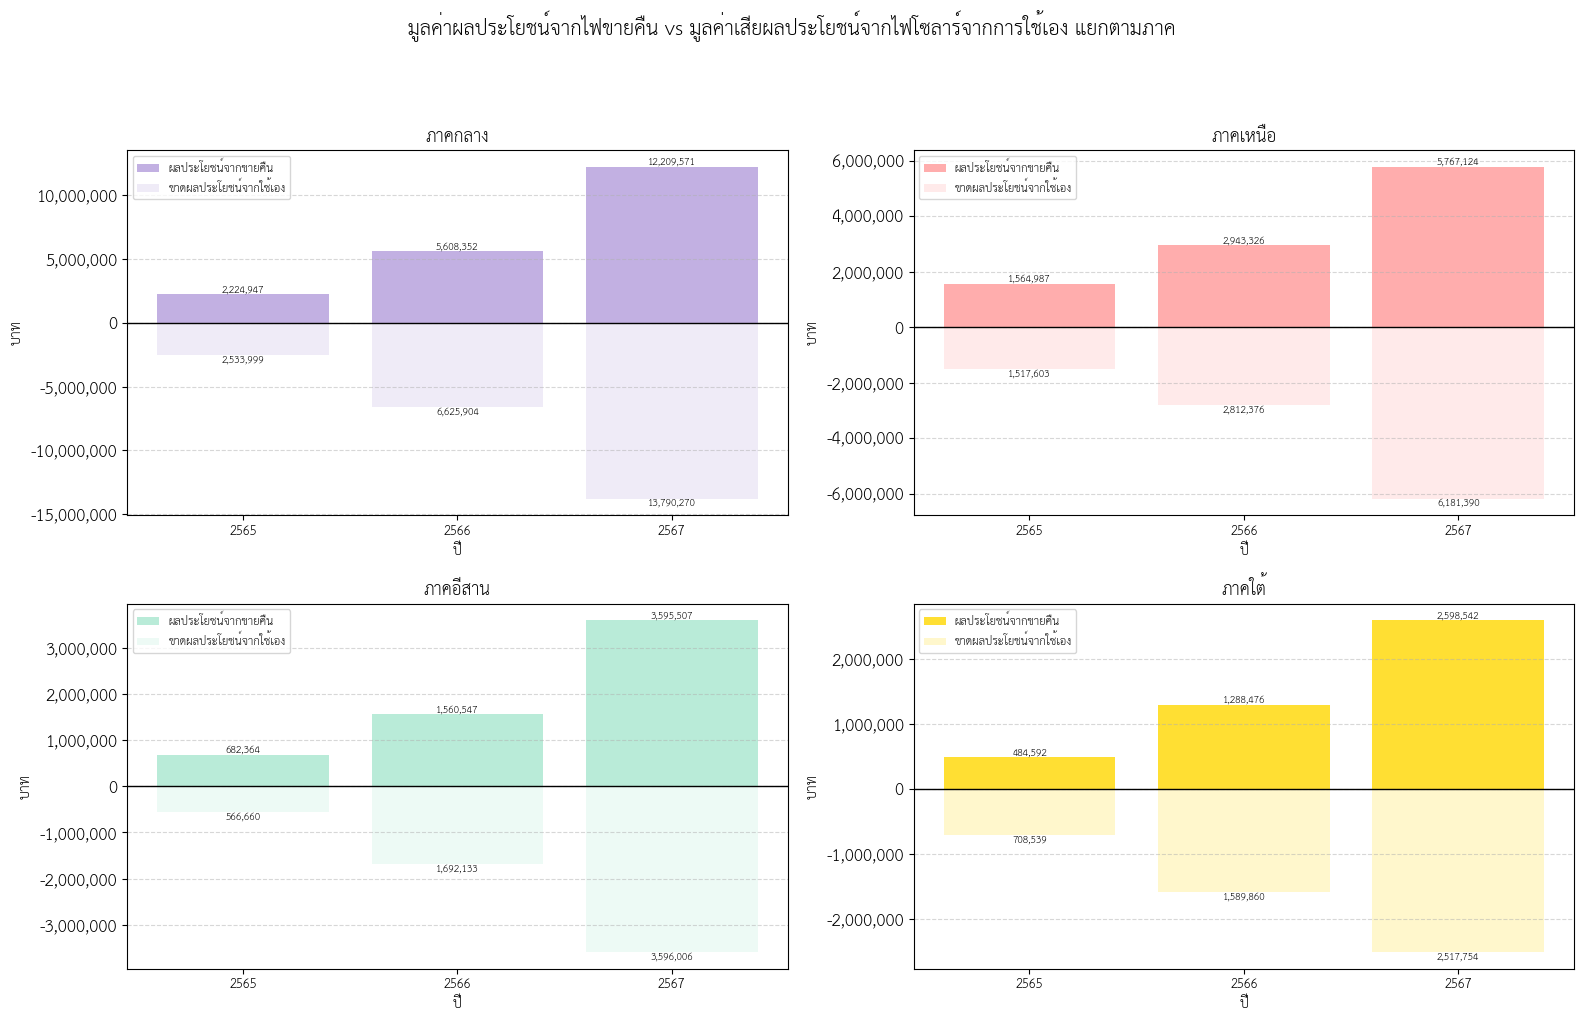

In [ ]:
# --- กราฟ 2: มูลค่าผลประโยชน์ (บาท) ---
years = sorted(df["ปี"].unique())
regions = ["กลาง", "เหนือ", "อีสาน", "ใต้"]
title_font = {'fontsize': 12, 'fontweight': 'bold'}
axis_font = {'fontsize': 10, 'fontweight': 'bold'}
tick_font = {'fontsize': 9}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]
    data_region = (
        df[df["ภาค"] == region]
        .groupby("ปี")[["ขาดกำไรจากการใช้เอง (บาท)", "กำไรจากไฟขายคืน (บาท)"]]
        .sum()
        .reset_index()
    )

    # ทำให้ "ขาดกำไร" เป็นค่าติดลบ
    data_region["ขาดกำไรติดลบ"] = data_region["ขาดกำไรจากการใช้เอง (บาท)"] * -1

    base_color = region_colors[region]  # สีตามภาค
    ax.set_title(f"ภาค{region}", **title_font)

    # พล็อตกำไร (ด้านบน)
    ax.bar(data_region["ปี"], data_region["กำไรจากไฟขายคืน (บาท)"],
           color=mcolors.to_rgba(base_color, alpha=color_sold_alpha),
           label="ผลประโยชน์จากขายคืน")

    # พล็อตขาดกำไร (ด้านล่าง)
    ax.bar(data_region["ปี"], data_region["ขาดกำไรติดลบ"],
           color=mcolors.to_rgba(base_color, alpha=color_self_alpha),
           label="ขาดผลประโยชน์จากใช้เอง")

    # ใส่ตัวเลขบนกราฟ
    for idx, row in data_region.iterrows():
        # ขาดกำไร (ค่าติดลบ → แสดงใต้แท่ง)
        ax.text(row["ปี"], row["ขาดกำไรติดลบ"] - 5000,
                f'{int(row["ขาดกำไรจากการใช้เอง (บาท)"]):,}',
                ha='center', va='top', fontsize=7)

        # กำไร (บวก → แสดงเหนือแท่ง)
        ax.text(row["ปี"], row["กำไรจากไฟขายคืน (บาท)"] + 5000,
                f'{int(row["กำไรจากไฟขายคืน (บาท)"]):,}',
                ha='center', va='bottom', fontsize=7)

    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel("บาท", **axis_font)
    ax.set_xlabel("ปี", **axis_font)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=0, **tick_font)
    ax.legend(fontsize=8, loc="upper left")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle("มูลค่าผลประโยชน์จากไฟขายคืน vs มูลค่าเสียผลประโยชน์จากไฟโซลาร์จากการใช้เอง แยกตามภาค",
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("มูลค่า2.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


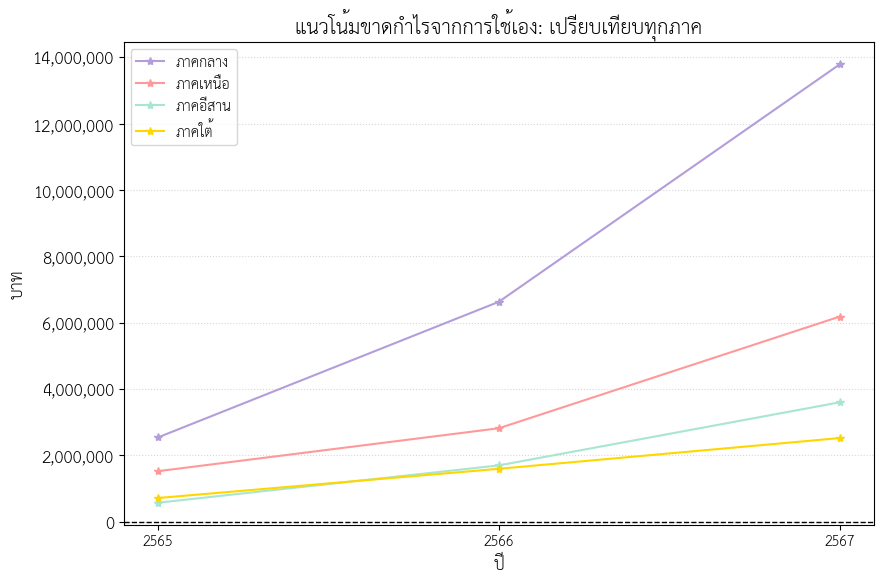

In [ ]:

# --- โฟลเดอร์เก็บรูป ---
output_dir = "output_charts"
os.makedirs(output_dir, exist_ok=True)

# --- ตั้งค่าฟอนต์ ---
title_font = {'fontsize': 14, 'fontweight': 'bold'}
axis_font = {'fontsize': 12}
tick_font = {'fontsize': 10}

# --- ตัวแปรที่ต้องมี ---
# regions = ["เหนือ", "กลาง", "อีสาน", "ใต้"]
# years = sorted(df["ปี"].unique())
# region_colors = {"เหนือ": "blue", "กลาง": "purple", "อีสาน": "green", "ใต้": "orange"}

# --- สร้าง Multi-line Chart รวมทุกภาค ---
plt.figure(figsize=(9, 6))
plt.title("แนวโน้มขาดกำไรจากการใช้เอง: เปรียบเทียบทุกภาค", **title_font)

for region in regions:
    data = df[df["ภาค"] == region].groupby("ปี")[["ขาดกำไรจากการใช้เอง (บาท)"]].sum().reset_index()
    plt.plot(
        data["ปี"],
        data["ขาดกำไรจากการใช้เอง (บาท)"],
        marker='*',
        linestyle='-',
        color=region_colors[region],
        label=f"ภาค{region}"
    )

# --- เส้นแนวนอน 0 ---
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# --- ปรับแกน ---
plt.ylabel("บาท", **axis_font)
plt.xlabel("ปี", **axis_font)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(fontsize=10)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(years, rotation=0, **tick_font)

# --- จัด layout ---
plt.tight_layout()

# --- บันทึกรูป ---
save_path = os.path.join(output_dir, "LineChart_แนวโน้มทุกภาค.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# --- แสดงกราฟ ---
plt.show()


In [ ]:
# เลือก Features ที่จะใช้เทรนโมเดล
features = ['กำลังการผลิตติดตั้ง(kwh)', 'ขายคืนรวมต่อปี', 'ใช้เองรวมต่อปี', 'ภาค']

# เป้าหมาย (Target)
target_col = 'ขาดกำไรจากการใช้เอง (บาท)'

# สร้าง X และ y
X = df[features].copy()
y = df[target_col]


In [ ]:
# One-hot encode คอลัมน์ 'ภาค'
categorical_features = ['ภาค']
numeric_features = [col for col in features if col not in categorical_features]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

# สร้าง Pipeline ของ XGBoost
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))
])


In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# เทรนโมเดล
xgb_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ภาค'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eva...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
# ทำนายผลบนชุดทดสอบ
y_pred = xgb_model.predict(X_test)

# คำนวณ Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 40.08903108337084
RMSE: 1134.6610976503985
R²: 0.8392342345680668


In [ ]:
# ปีที่ต้องการพยากรณ์
future_years = [2568, 2569, 2570]
regions = list(df['ภาค'].unique()) + ['รวมประเทศ']

# สมมติ Scenario การเติบโต
scenarios = {
    "Base Forecast": {"install_growth": 1.0, "selfuse_growth": 1.0},
    "+10%": {"install_growth": 1.1, "selfuse_growth": 1.1},
    "+20%": {"install_growth": 1.2, "selfuse_growth": 1.2},
    "+50%": {"install_growth": 1.5, "selfuse_growth": 1.5},
}


In [ ]:
# เทรนโมเดลใหม่บนข้อมูลทั้งหมด
xgb_model.fit(X, y)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ภาค'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eva...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
forecast_by_region = {region:{} for region in regions}

for scenario_name, growth in scenarios.items():
    # --- แยกรายภาค ---
    for region in df['ภาค'].unique():
        df_region = df[df['ภาค']==region].copy()
        y_forecast_yearly = []
        current_df = df_region.copy()

        for year in future_years:
            current_df['กำลังการผลิตติดตั้ง(kwh)'] *= growth['install_growth']
            current_df['ใช้เองรวมต่อปี'] *= growth['selfuse_growth']
            current_df['ขายคืนรวมต่อปี'] *= growth['selfuse_growth']

            y_year = xgb_model.predict(current_df[features]).sum()
            y_forecast_yearly.append(y_year)

        forecast_by_region[region][scenario_name] = y_forecast_yearly

    # --- รวมประเทศ ---
    df_all = df.copy()
    y_forecast_yearly = []
    current_df = df_all.copy()

    for year in future_years:
        current_df['กำลังการผลิตติดตั้ง(kwh)'] *= growth['install_growth']
        current_df['ใช้เองรวมต่อปี'] *= growth['selfuse_growth']
        current_df['ขายคืนรวมต่อปี'] *= growth['selfuse_growth']

        y_year = xgb_model.predict(current_df[features]).sum()
        y_forecast_yearly.append(y_year)

    forecast_by_region['รวมประเทศ'][scenario_name] = y_forecast_yearly


In [ ]:

x_smooth = np.linspace(min(future_years), max(future_years), 100)
colors = ["red", "orange", "purple", "blue","green"]

for region in regions:
    fig = go.Figure()

    for i, (scenario, y_data) in enumerate(forecast_by_region[region].items()):
        spline = make_interp_spline(future_years, y_data, k=2)
        y_smooth = spline(x_smooth)

        fig.add_trace(go.Scatter(
            x=x_smooth, y=y_smooth, mode="lines",
            name=scenario,
            line=dict(color=colors[i], dash="dot" if scenario=="Base Forecast" else "solid")
        ))

        fig.add_trace(go.Scatter(
            x=future_years, y=y_data, mode="markers+text",
            marker=dict(color=colors[i], size=8),
            text=[f"{int(v):,}" for v in y_data],
            textposition="top center",
            textfont=dict(size=10),
            showlegend=False
        ))

    # กำหนด title ตามว่าเป็นกราฟรวมประเทศหรือแยกภาค
    if region == "รวมประเทศ":  # สมมติคุณเพิ่มชื่อ key นี้ใน forecast_by_region
        title_text = "Forecast ผลกระทบต่อรายได้ PEA จาก Solar Rooftop - ภาพรวมประเทศ (2568–2570)"
    else:
        title_text = f"Forecast ผลกระทบต่อรายได้ PEA จาก Solar Rooftop - ภาค {region} (2568–2570)"

    fig.update_layout(
        title=title_text,
        xaxis=dict(title="ปี (พ.ศ.)", tickmode='array', tickvals=future_years, ticktext=[str(y) for y in future_years]),
        yaxis=dict(title="มูลค่าการสูญเสียรายได้จากโซลาร์ใช้เอง (บาท)", tickformat=","),
        template="plotly_white", width=1200, height=700,
        plot_bgcolor='rgba(230, 230, 250, 0.3)', paper_bgcolor='rgba(255, 255, 255, 1)',
        legend=dict(x=1.02, y=1, xanchor='left', yanchor='top', bgcolor="rgba(255,255,255,0.6)")
    )

    fig.show()
